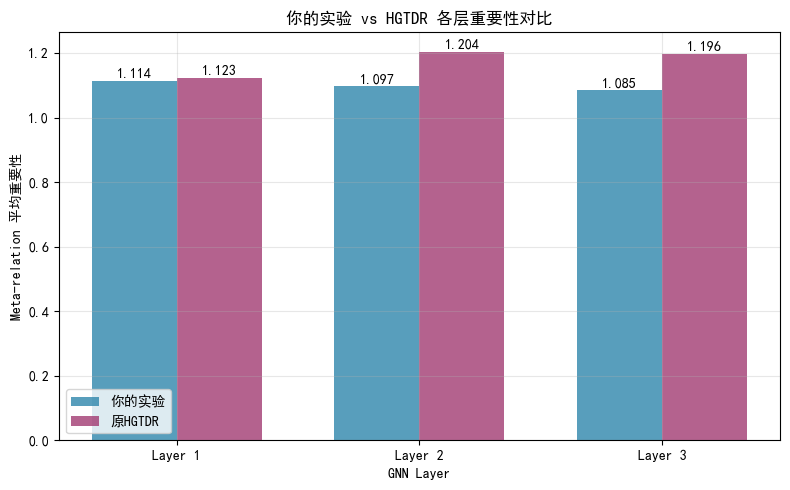

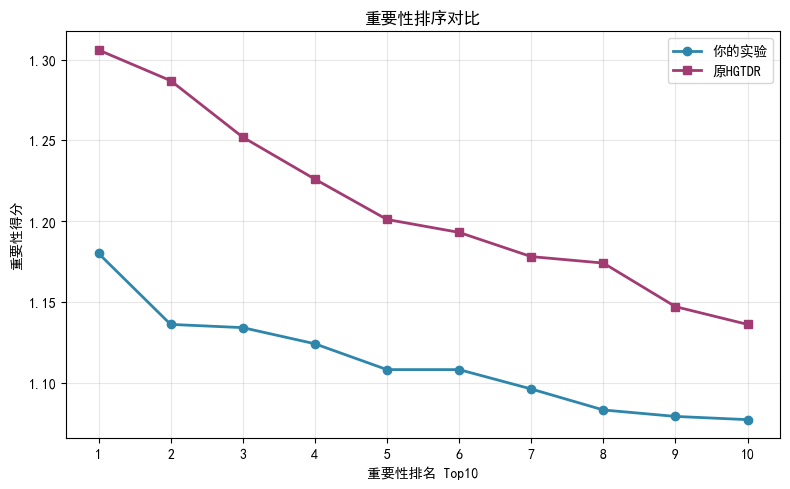

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1. 解决中文显示问题
# --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # Windows
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']    # Mac
plt.rcParams['axes.unicode_minus'] = False

# --------------------------
# 2. 读取你的数据 + 原HGTDR数据
# --------------------------
# 你的数据
user_data = pd.read_csv(r"D:\Code\python_deeplearning\HGTDR\out\HGTDR-15-3\meta_relation_importance.csv")
user_data.columns = ['Layer', 'Source_Type', 'Edge_Type', 'Target_Type', 'Importance']

# 原HGTDR数据（我手动整理好的）
hgtdr_data = {
    'Layer': ['Layer 3', 'Layer 3', 'Layer 3', 'Layer 3', 'Layer 3',
              'Layer 2', 'Layer 2', 'Layer 2', 'Layer 2', 'Layer 2',
              'Layer 1', 'Layer 1', 'Layer 1', 'Layer 1', 'Layer 1'],
    'Source_Type': ['Disease', 'Disease', 'Drug', 'Protein', 'Phenotype',
                   'Disease', 'Protein', 'Disease', 'Disease', 'Phenotype',
                   'Disease', 'Disease', 'Protein', 'Protein', 'Exposure'],
    'Edge_Type': ['Contraindication', 'Disease-disease', 'Off-label use', 'Drug-protein', 'Drug-phenotype',
                 'Disease-disease', 'Phenotype-protein', 'Contraindication', 'Off-label use', 'Disease-phenotype-positive',
                 'Off-label use', 'Disease-disease', 'Drug-protein', 'Phenotype-protein', 'Exposure-protein'],
    'Target_Type': ['Drug', 'Disease', 'Disease', 'Drug', 'Drug',
                   'Disease', 'Phenotype', 'Drug', 'Drug', 'Disease',
                   'Drug', 'Disease', 'Drug', 'Phenotype', 'Protein'],
    'Importance': [1.306, 1.287, 1.174, 1.122, 1.091,
                  1.252, 1.226, 1.201, 1.193, 1.147,
                  1.178, 1.136, 1.121, 1.102, 1.079]
}
hgtdr_data = pd.DataFrame(hgtdr_data)

# --------------------------
# 3. 计算各层平均重要性（绘图用）
# --------------------------
layers = ['Layer 1', 'Layer 2', 'Layer 3']
user_mean = [user_data[user_data['Layer']==l]['Importance'].mean() for l in layers]
hgtdr_mean = [hgtdr_data[hgtdr_data['Layer']==l]['Importance'].mean() for l in layers]

# --------------------------
# 4. 绘制【各层平均重要性对比图】
# --------------------------
plt.figure(figsize=(8, 5))
x = np.arange(len(layers))
width = 0.35

plt.bar(x - width/2, user_mean, width, label='你的实验', color='#2E86AB', alpha=0.8)
plt.bar(x + width/2, hgtdr_mean, width, label='原HGTDR', color='#A23B72', alpha=0.8)

# 加数值标签
for i, v in enumerate(user_mean):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(hgtdr_mean):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.xlabel('GNN Layer')
plt.ylabel('Meta-relation 平均重要性')
plt.title('你的实验 vs HGTDR 各层重要性对比')
plt.xticks(x, layers)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('layer_importance_compare.png', dpi=300)
plt.show()

# --------------------------
# 5. 绘制【Top10 重要性排序对比图】
# --------------------------
user_top10 = user_data.nlargest(10, 'Importance')['Importance'].values
hgtdr_top10 = hgtdr_data.nlargest(10, 'Importance')['Importance'].values

plt.figure(figsize=(8, 5))
plt.plot(range(1,11), user_top10, marker='o', label='你的实验', linewidth=2, color='#2E86AB')
plt.plot(range(1,11), hgtdr_top10, marker='s', label='原HGTDR', linewidth=2, color='#A23B72')

plt.xlabel('重要性排名 Top10')
plt.ylabel('重要性得分')
plt.title('重要性排序对比')
plt.xticks(range(1,11))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('top10_importance_rank.png', dpi=300)
plt.show()